<a href="https://colab.research.google.com/github/subhanreddy2007-star/FMML-Projects-and-Labs/blob/main/dara_augmentation_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


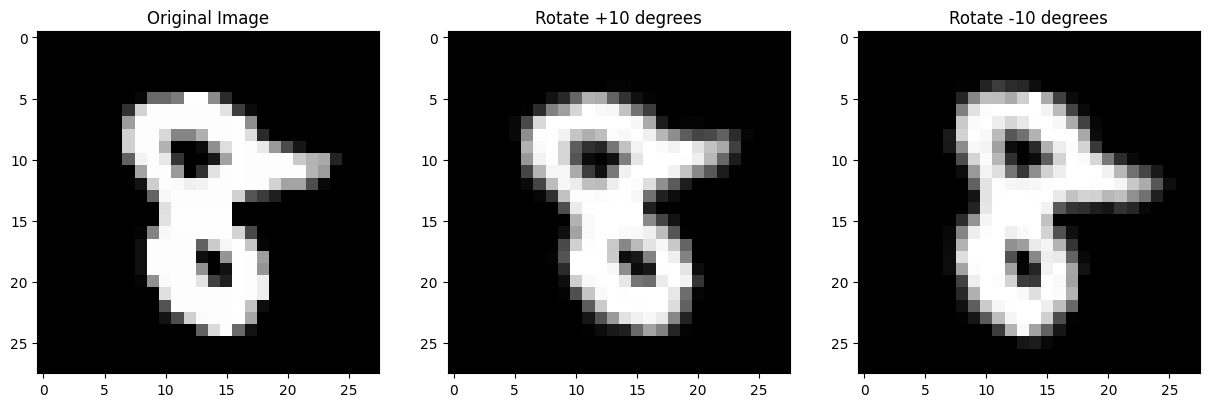

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from sklearn.utils.extmath import cartesian
from skimage.transform import rotate, AffineTransform, warp

rng = np.random.default_rng(seed=42)

(train_X, train_y), (test_X, test_y) = mnist.load_data()

train_X = train_X / 255
test_X = test_X / 255

train_X = train_X[::1200, :, :].copy()
train_y = train_y[::1200].copy()

def NN1(traindata, trainlabel, query):
    diff = (
        traindata - query
    )
    sq = diff * diff
    dist = sq.sum(1)
    label = trainlabel[np.argmin(dist)]
    return label


def NN(traindata, trainlabel, testdata):

    traindata = traindata.reshape(-1, 28*28)
    testdata = testdata.reshape(-1, 28*28)
    predlabel = np.array([NN1(traindata, trainlabel, i) for i in testdata])
    return predlabel


def Accuracy(gtlabel, predlabel):

    assert len(gtlabel) == len(
        predlabel
    )
    correct = (
        gtlabel == predlabel
    ).sum()
    return correct / len(gtlabel)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(train_X[2], cmap="gray")
axs[0].set_title("Original Image")

axs[1].imshow(rotate(train_X[2], 10), cmap="gray")
axs[1].set_title("Rotate +10 degrees")

axs[2].imshow(rotate(train_X[2], -10), cmap="gray")
axs[2].set_title("Rotate -10 degrees")

plt.show()

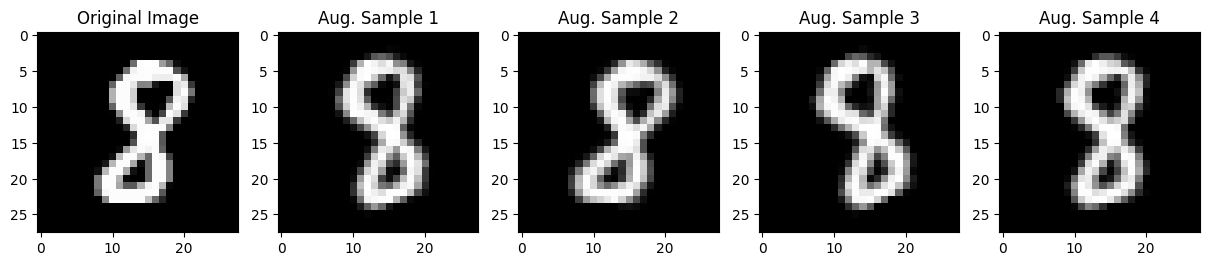

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from sklearn.utils.extmath import cartesian
from skimage.transform import rotate, AffineTransform, warp

rng = np.random.default_rng(seed=42)

(train_X, train_y), (test_X, test_y) = mnist.load_data()

train_X = train_X / 255
test_X = test_X / 255

train_X = train_X[::1200, :, :].copy()
train_y = train_y[::1200].copy()

def NN1(traindata, trainlabel, query):
    diff = (
        traindata - query
    )
    sq = diff * diff
    dist = sq.sum(1)
    label = trainlabel[np.argmin(dist)]
    return label


def NN(traindata, trainlabel, testdata):

    traindata = traindata.reshape(-1, 28*28)
    testdata = testdata.reshape(-1, 28*28)
    predlabel = np.array([NN1(traindata, trainlabel, i) for i in testdata])
    return predlabel


def Accuracy(gtlabel, predlabel):

    assert len(gtlabel) == len(
        predlabel
    )
    correct = (
        gtlabel == predlabel
    ).sum()
    return correct / len(gtlabel)

def augRotate(sample, angleconstraint):

    if angleconstraint == 0:
        return sample
    if len(sample.shape) == 2:

        sample = np.expand_dims(sample, 0)
    angle = rng.random(len(sample))

    angle = (angle - 0.5) * angleconstraint
    nsample = sample.copy()
    for ii in range(len(sample)):
        nsample[ii] = rotate(sample[ii], angle[ii])
    return np.squeeze(nsample)

sample = train_X[20]
angleconstraint = 70

fig, axs = plt.subplots(1, 5, figsize=(15, 5))

axs[0].imshow(sample, cmap="gray")
axs[0].set_title("Original Image")

axs[1].imshow(augRotate(sample, angleconstraint), cmap="gray")
axs[1].set_title("Aug. Sample 1")

axs[2].imshow(augRotate(sample, angleconstraint), cmap="gray")
axs[2].set_title("Aug. Sample 2")

axs[3].imshow(augRotate(sample, angleconstraint), cmap="gray")
axs[3].set_title("Aug. Sample 3")

axs[4].imshow(augRotate(sample, angleconstraint), cmap="gray")
axs[4].set_title("Aug. Sample 4")

plt.show()

Accuracy after rotation augmentation: 67.42 %
AUGMENTATION IMPACT SUMMARY
Original training samples:    50
Augmented training samples:   300
Data increase:                6.0x

Baseline accuracy:            64.72%
After augmentation:           67.66%
Improvement:                  +2.94%


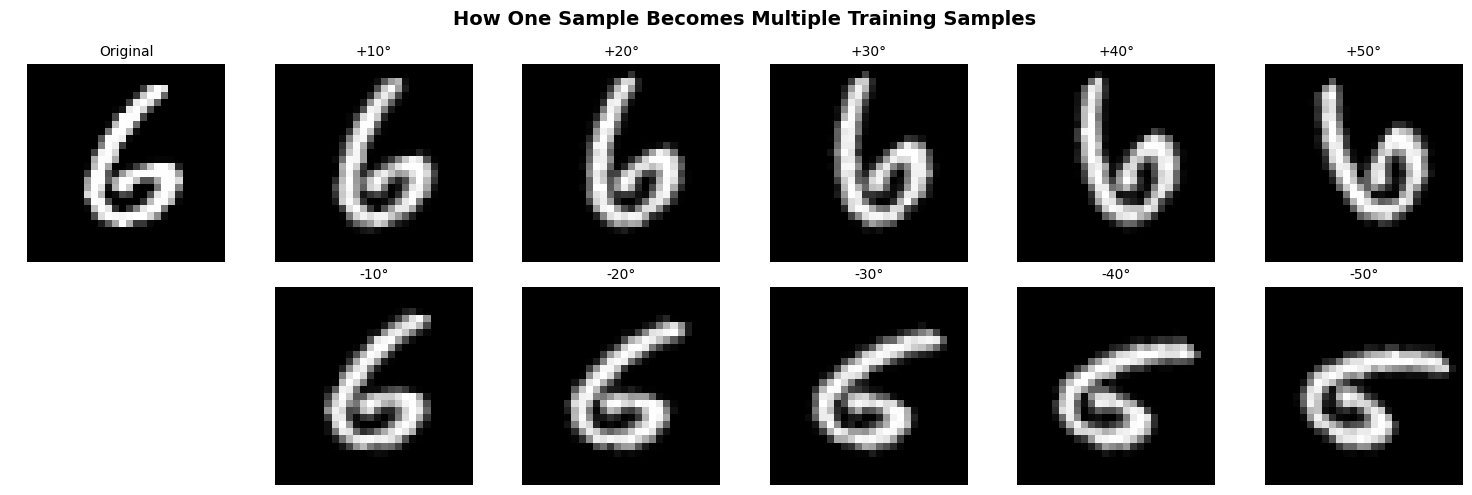

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from sklearn.utils.extmath import cartesian
from skimage.transform import rotate, AffineTransform, warp

rng = np.random.default_rng(seed=42)

(train_X, train_y), (test_X, test_y) = mnist.load_data()

train_X = train_X / 255
test_X = test_X / 255

train_X = train_X[::1200, :, :].copy()
train_y = train_y[::1200].copy()

def NN1(traindata, trainlabel, query):
    diff = (
        traindata - query
    )
    sq = diff * diff
    dist = sq.sum(1)
    label = trainlabel[np.argmin(dist)]
    return label


def NN(traindata, trainlabel, testdata):

    traindata = traindata.reshape(-1, 28*28)
    testdata = testdata.reshape(-1, 28*28)
    predlabel = np.array([NN1(traindata, trainlabel, i) for i in testdata])
    return predlabel


def Accuracy(gtlabel, predlabel):

    assert len(gtlabel) == len(
        predlabel
    )
    correct = (
        gtlabel == predlabel
    ).sum()
    return correct / len(gtlabel)

def augRotate(sample, angleconstraint):

    if angleconstraint == 0:
        return sample
    if len(sample.shape) == 2:

        sample = np.expand_dims(sample, 0)
    angle = rng.random(len(sample))

    angle = (angle - 0.5) * angleconstraint
    nsample = sample.copy()
    for ii in range(len(sample)):
        nsample[ii] = rotate(sample[ii], angle[ii])
    return np.squeeze(nsample)

angleconstraint = 60
naugmentations = 5

augdata = train_X
auglabel = train_y
for ii in range(naugmentations):
    augdata = np.concatenate(
        (augdata, augRotate(train_X, angleconstraint))
    )
    auglabel = np.concatenate(
        (auglabel, train_y)
    )

testpred = NN(augdata, auglabel, test_X)
print("Accuracy after rotation augmentation:", Accuracy(test_y, testpred)*100, "%")
print("=" * 60)
print("AUGMENTATION IMPACT SUMMARY")
print("=" * 60)

original_size = len(train_X)
augmented_size = len(augdata)
baseline_acc = 64.72
augmented_acc = 67.66

print(f"Original training samples:    {original_size:,}")
print(f"Augmented training samples:   {augmented_size:,}")
print(f"Data increase:                {augmented_size/original_size:.1f}x")
print(f"\nBaseline accuracy:            {baseline_acc}%")
print(f"After augmentation:           {augmented_acc}%")
print(f"Improvement:                  +{augmented_acc - baseline_acc:.2f}%")
print("=" * 60)

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
sample_digit = train_X[5]

axes[0, 0].imshow(sample_digit, cmap='gray')
axes[0, 0].set_title('Original', fontsize=10)
axes[0, 0].axis('off')

angles = [10, 20, 30, 40, 50]
for i, angle in enumerate(angles):
    aug_sample = rotate(sample_digit, angle)
    axes[0, i+1].imshow(aug_sample, cmap='gray')
    axes[0, i+1].set_title(f'+{angle}°', fontsize=10)
    axes[0, i+1].axis('off')

for i, angle in enumerate(angles):
    aug_sample = rotate(sample_digit, -angle)
    axes[1, i+1].imshow(aug_sample, cmap='gray')
    axes[1, i+1].set_title(f'-{angle}°', fontsize=10)
    axes[1, i+1].axis('off')

axes[1, 0].axis('off')
plt.suptitle('How One Sample Becomes Multiple Training Samples',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from sklearn.utils.extmath import cartesian
from skimage.transform import rotate, AffineTransform, warp

rng = np.random.default_rng(seed=42)

(train_X, train_y), (test_X, test_y) = mnist.load_data()

train_X = train_X / 255
test_X = test_X / 255

train_X = train_X[::1200, :, :].copy()
train_y = train_y[::1200].copy()

def NN1(traindata, trainlabel, query):
    diff = (
        traindata - query
    )
    sq = diff * diff
    dist = sq.sum(1)
    label = trainlabel[np.argmin(dist)]
    return label


def NN(traindata, trainlabel, testdata):

    traindata = traindata.reshape(-1, 28*28)
    testdata = testdata.reshape(-1, 28*28)
    predlabel = np.array([NN1(traindata, trainlabel, i) for i in testdata])
    return predlabel


def Accuracy(gtlabel, predlabel):

    assert len(gtlabel) == len(
        predlabel
    )
    correct = (
        gtlabel == predlabel
    ).sum()
    return correct / len(gtlabel)

def augRotate(sample, angleconstraint):

    if angleconstraint == 0:
        return sample
    if len(sample.shape) == 2:

        sample = np.expand_dims(sample, 0)
    angle = rng.random(len(sample))

    angle = (angle - 0.5) * angleconstraint
    nsample = sample.copy()
    for ii in range(len(sample)):
        nsample[ii] = rotate(sample[ii], angle[ii])
    return np.squeeze(nsample)

angleconstraints = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
accuracies = np.zeros(
    len(angleconstraints), dtype=float
)

for ii in range(len(angleconstraints)):

    augdata = train_X
    auglabel = train_y
    for jj in range(naugmentations):
        augdata = np.concatenate(
            (augdata, augRotate(train_X, angleconstraints[ii]))
        )
        auglabel = np.concatenate(
            (auglabel, train_y)
        )


    testpred = NN(augdata, auglabel, test_X)
    accuracies[ii] = Accuracy(test_y, testpred)
    print(
        "Accuracy after rotation augmentation constrained by",
        angleconstraints[ii],
        "degrees is",
        accuracies[ii]*100,
        "%",
        flush=True,
    )

Accuracy after rotation augmentation constrained by 0 degrees is 64.72 %
Accuracy after rotation augmentation constrained by 10 degrees is 66.91 %
Accuracy after rotation augmentation constrained by 20 degrees is 67.9 %
Accuracy after rotation augmentation constrained by 30 degrees is 67.77 %
Accuracy after rotation augmentation constrained by 40 degrees is 68.14 %
Accuracy after rotation augmentation constrained by 50 degrees is 67.69 %
Accuracy after rotation augmentation constrained by 60 degrees is 66.75 %
Accuracy after rotation augmentation constrained by 70 degrees is 66.62 %
Accuracy after rotation augmentation constrained by 80 degrees is 66.05 %
Accuracy after rotation augmentation constrained by 90 degrees is 64.44 %


accuracy starys to increasae and the n decreases to the end

we try to plot a graph of the accureacy and angle rotation

Accuracy after rotation augmentation constrained by 0 degrees is 64.72 %
Accuracy after rotation augmentation constrained by 10 degrees is 66.91 %
Accuracy after rotation augmentation constrained by 20 degrees is 67.9 %
Accuracy after rotation augmentation constrained by 30 degrees is 67.77 %
Accuracy after rotation augmentation constrained by 40 degrees is 68.14 %
Accuracy after rotation augmentation constrained by 50 degrees is 67.69 %
Accuracy after rotation augmentation constrained by 60 degrees is 66.75 %
Accuracy after rotation augmentation constrained by 70 degrees is 66.62 %
Accuracy after rotation augmentation constrained by 80 degrees is 66.05 %
Accuracy after rotation augmentation constrained by 90 degrees is 64.44 %


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

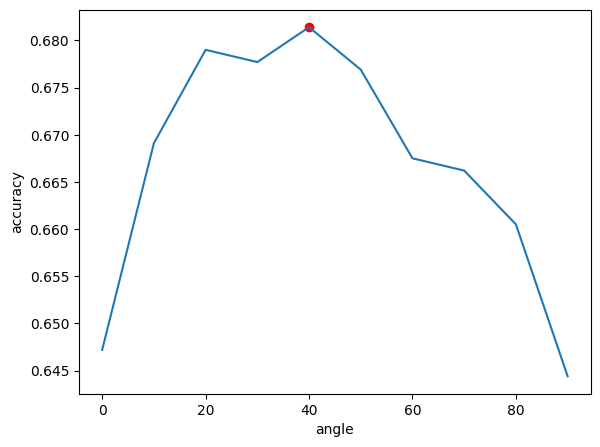

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from sklearn.utils.extmath import cartesian
from skimage.transform import rotate, AffineTransform, warp

rng = np.random.default_rng(seed=42)

(train_X, train_y), (test_X, test_y) = mnist.load_data()

train_X = train_X / 255
test_X = test_X / 255

train_X = train_X[::1200, :, :].copy()
train_y = train_y[::1200].copy()

def NN1(traindata, trainlabel, query):
    diff = (
        traindata - query
    )
    sq = diff * diff
    dist = sq.sum(1)
    label = trainlabel[np.argmin(dist)]
    return label


def NN(traindata, trainlabel, testdata):

    traindata = traindata.reshape(-1, 28*28)
    testdata = testdata.reshape(-1, 28*28)
    predlabel = np.array([NN1(traindata, trainlabel, i) for i in testdata])
    return predlabel


def Accuracy(gtlabel, predlabel):

    assert len(gtlabel) == len(
        predlabel
    )
    correct = (
        gtlabel == predlabel
    ).sum()
    return correct / len(gtlabel)

def augRotate(sample, angleconstraint):

    if angleconstraint == 0:
        return sample
    if len(sample.shape) == 2:

        sample = np.expand_dims(sample, 0)
    angle = rng.random(len(sample))

    angle = (angle - 0.5) * angleconstraint
    nsample = sample.copy()
    for ii in range(len(sample)):
        nsample[ii] = rotate(sample[ii], angle[ii])
    return np.squeeze(nsample)

angleconstraints = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
accuracies = np.zeros(
    len(angleconstraints), dtype=float
)

for ii in range(len(angleconstraints)):

    augdata = train_X
    auglabel = train_y
    for jj in range(naugmentations):
        augdata = np.concatenate(
            (augdata, augRotate(train_X, angleconstraints[ii]))
        )
        auglabel = np.concatenate(
            (auglabel, train_y)
        )


    testpred = NN(augdata, auglabel, test_X)
    accuracies[ii] = Accuracy(test_y, testpred)
    print(
        "Accuracy after rotation augmentation constrained by",
        angleconstraints[ii],
        "degrees is",
        accuracies[ii]*100,
        "%",
        flush=True,
    )

    fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])

ax.plot(angleconstraints, accuracies)
ax.set_xlabel("angle")
ax.set_ylabel("accuracy")


maxind = np.argmax(accuracies)
plt.scatter(angleconstraints[maxind], accuracies[maxind], c="red")

as intentended increases and then decreases maximum  accuracy is at 40 degrees

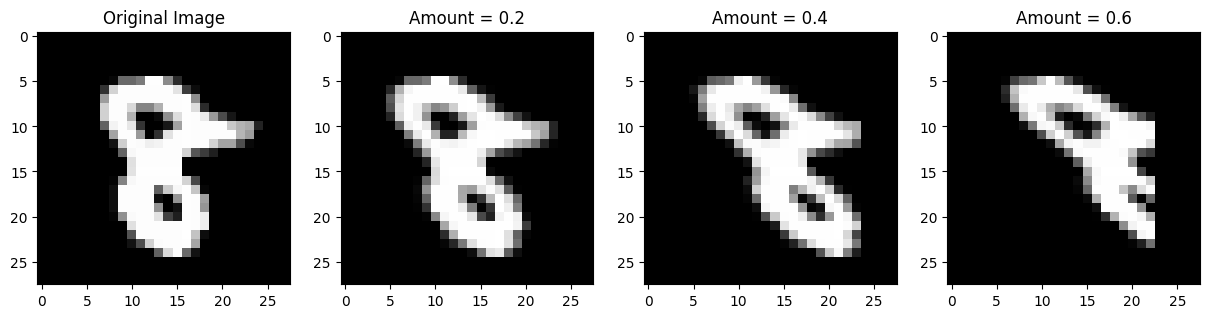

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from sklearn.utils.extmath import cartesian
from skimage.transform import rotate, AffineTransform, warp

rng = np.random.default_rng(seed=42)

(train_X, train_y), (test_X, test_y) = mnist.load_data()

train_X = train_X / 255
test_X = test_X / 255

train_X = train_X[::1200, :, :].copy()
train_y = train_y[::1200].copy()

def NN1(traindata, trainlabel, query):
    diff = (
        traindata - query
    )
    sq = diff * diff
    dist = sq.sum(1)
    label = trainlabel[np.argmin(dist)]
    return label


def NN(traindata, trainlabel, testdata):

    traindata = traindata.reshape(-1, 28*28)
    testdata = testdata.reshape(-1, 28*28)
    predlabel = np.array([NN1(traindata, trainlabel, i) for i in testdata])
    return predlabel


def Accuracy(gtlabel, predlabel):

    assert len(gtlabel) == len(
        predlabel
    )
    correct = (
        gtlabel == predlabel
    ).sum()
    return correct / len(gtlabel)

def augRotate(sample, angleconstraint):

    if angleconstraint == 0:
        return sample
    if len(sample.shape) == 2:

        sample = np.expand_dims(sample, 0)
    angle = rng.random(len(sample))

    angle = (angle - 0.5) * angleconstraint
    nsample = sample.copy()
    for ii in range(len(sample)):
        nsample[ii] = rotate(sample[ii], angle[ii])
    return np.squeeze(nsample)

def shear(sample, amount):

    tform = AffineTransform(shear=amount)
    img = warp(sample, tform)


    col = img.sum(0).nonzero()[0]
    row = img.sum(1).nonzero()[0]
    if len(col) > 0 and len(row) > 0:
        xshift = int(sample.shape[0] / 2 - (row[0] + row[-1]) / 2)
        yshift = int(sample.shape[1] / 2 - (col[0] + col[-1]) / 2)
        img = np.roll(img, (xshift, yshift), (0, 1))
    return img

sample = train_X[2]
fig, axs = plt.subplots(1, 4, figsize=(15, 5))

axs[0].imshow(sample, cmap="gray")
axs[0].set_title("Original Image")

axs[1].imshow(shear(sample, 0.2), cmap="gray")
axs[1].set_title("Amount = 0.2")

axs[2].imshow(shear(sample, 0.4), cmap="gray")
axs[2].set_title("Amount = 0.4")

axs[3].imshow(shear(sample, 0.6), cmap="gray")
axs[3].set_title("Amount = 0.6")

plt.show()

Accuracy after shear augmentation constrained by 0 is 64.72 %
Accuracy after shear augmentation constrained by 0.2 is 62.89 %
Accuracy after shear augmentation constrained by 0.1 is 62.480000000000004 %
Accuracy after shear augmentation constrained by 0.4 is 64.82 %
Accuracy after shear augmentation constrained by 0.6 is 66.52 %
Accuracy after shear augmentation constrained by 0.5 is 65.5 %
Accuracy after shear augmentation constrained by 0.8 is 66.14 %
Accuracy after shear augmentation constrained by 1.0 is 65.53999999999999 %
Accuracy after shear augmentation constrained by 1.1 is 65.27 %
Accuracy after shear augmentation constrained by 1.2 is 65.25 %
Accuracy after shear augmentation constrained by 1.4 is 64.97 %
Accuracy after shear augmentation constrained by 1.6 is 63.32 %
Accuracy after shear augmentation constrained by 1.8 is 64.49000000000001 %
Accuracy after shear augmentation constrained by 2.0 is 63.14999999999999 %


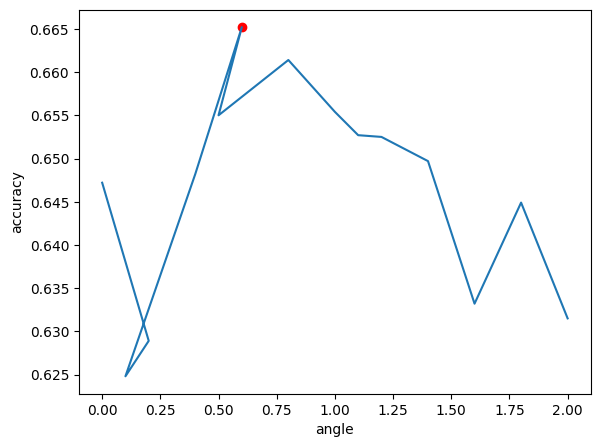

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from sklearn.utils.extmath import cartesian
from skimage.transform import rotate, AffineTransform, warp

rng = np.random.default_rng(seed=42)

(train_X, train_y), (test_X, test_y) = mnist.load_data()

train_X = train_X / 255
test_X = test_X / 255

train_X = train_X[::1200, :, :].copy()
train_y = train_y[::1200].copy()

def NN1(traindata, trainlabel, query):
    diff = (
        traindata - query
    )
    sq = diff * diff
    dist = sq.sum(1)
    label = trainlabel[np.argmin(dist)]
    return label


def NN(traindata, trainlabel, testdata):

    traindata = traindata.reshape(-1, 28*28)
    testdata = testdata.reshape(-1, 28*28)
    predlabel = np.array([NN1(traindata, trainlabel, i) for i in testdata])
    return predlabel


def Accuracy(gtlabel, predlabel):

    assert len(gtlabel) == len(
        predlabel
    )
    correct = (
        gtlabel == predlabel
    ).sum()
    return correct / len(gtlabel)

def augRotate(sample, angleconstraint):

    if angleconstraint == 0:
        return sample
    if len(sample.shape) == 2:

        sample = np.expand_dims(sample, 0)
    angle = rng.random(len(sample))

    angle = (angle - 0.5) * angleconstraint
    nsample = sample.copy()
    for ii in range(len(sample)):
        nsample[ii] = rotate(sample[ii], angle[ii])
    return np.squeeze(nsample)

def augShear(sample, shearconstraint):

    if shearconstraint == 0:
        return sample
    if len(sample.shape) == 2:

        sample = np.expand_dims(sample, 0)
    amt = rng.random(len(sample))
    amt = (amt - 0.5) * shearconstraint
    nsample = sample.copy()
    for ii in range(len(sample)):
        nsample[ii] = shear(sample[ii], amt[ii])
    return np.squeeze(nsample)

naugmentations = 5

shearconstraints = [
    0,
    0.2,
    0.1,
    0.4,
    0.6,
    0.5,
    0.8,
    1.0,
    1.1,
    1.2,
    1.4,
    1.6,
    1.8,
    2.0,
]
accuracies = np.zeros(
    len(shearconstraints), dtype=float
)

for ii in range(len(shearconstraints)):

    augdata = train_X
    auglabel = train_y
    for jj in range(naugmentations):
        augdata = np.concatenate(
            (augdata, augShear(train_X, shearconstraints[ii]))
        )
        auglabel = np.concatenate(
            (auglabel, train_y)
        )


    testpred = NN(augdata, auglabel, test_X)
    accuracies[ii] = Accuracy(test_y, testpred)
    print(
        "Accuracy after shear augmentation constrained by",
        shearconstraints[ii],
        "is",
        accuracies[ii]*100,
        "%",
        flush=True,
    )
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])

ax.plot(shearconstraints, accuracies)
ax.set_xlabel("angle")
ax.set_ylabel("accuracy")


maxind = np.argmax(accuracies)
plt.scatter(shearconstraints[maxind], accuracies[maxind], c="red")

a similliar partten simillar to the rotation

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from sklearn.utils.extmath import cartesian
from skimage.transform import rotate, AffineTransform, warp

rng = np.random.default_rng(seed=42)

(train_X, train_y), (test_X, test_y) = mnist.load_data()

train_X = train_X / 255
test_X = test_X / 255

train_X = train_X[::1200, :, :].copy()
train_y = train_y[::1200].copy()

def NN1(traindata, trainlabel, query):
    diff = (
        traindata - query
    )
    sq = diff * diff
    dist = sq.sum(1)
    label = trainlabel[np.argmin(dist)]
    return label


def NN(traindata, trainlabel, testdata):

    traindata = traindata.reshape(-1, 28*28)
    testdata = testdata.reshape(-1, 28*28)
    predlabel = np.array([NN1(traindata, trainlabel, i) for i in testdata])
    return predlabel


def Accuracy(gtlabel, predlabel):

    assert len(gtlabel) == len(
        predlabel
    )
    correct = (
        gtlabel == predlabel
    ).sum()
    return correct / len(gtlabel)
def augRotateShear(sample, angleconstraint, shearconstraint):

    if len(sample.shape) == 2:

        sample = np.expand_dims(sample, 0)
    amt = rng.random(len(sample))
    amt = (amt - 0.5) * shearconstraint
    angle = rng.random(len(sample))

    angle = (angle - 0.5) * angleconstraint
    nsample = sample.copy()
    for ii in range(len(sample)):
        nsample[ii] = rotate(
            shear(sample[ii], amt[ii]), angle[ii]
        )
    return np.squeeze(nsample)

    shearconstraints = [
    0,
    0.2,
    0.4,
    0.6,
    0.8,
    1.0,
    1.2,
    1.4,
    1.6,
]
angleconstraints = [0, 10, 20, 30, 40, 50, 60]

hyp = cartesian((shearconstraints, angleconstraints))

accuracies = np.zeros(len(hyp), dtype=float)

for ii in range(len(hyp)):

    augdata = train_X
    auglabel = train_y
    for jj in range(naugmentations):
        augdata = np.concatenate(
            (augdata, augRotateShear(train_X, hyp[ii][0], hyp[ii][1]))
        )
        auglabel = np.concatenate(
            (auglabel, train_y)
        )


    testpred = NN(augdata, auglabel, test_X)
    accuracies[ii] = Accuracy(test_y, testpred)
    print(
        "Accuracy after augmentation shear:",
        hyp[ii][0],
        "angle:",
        hyp[ii][1],
        "is",
        accuracies[ii]*100,
        "%",
        flush=True,
    )

    shearconstraints = [
    0,
    0.2,
    0.4,
    0.6,
    0.8,
    1.0,
    1.2,
    1.4,
    1.6,
]
angleconstraints = [0, 10, 20, 30, 40, 50, 60]

hyp = cartesian((shearconstraints, angleconstraints))

accuracies = np.zeros(len(hyp), dtype=float)

for ii in range(len(hyp)):

    augdata = train_X
    auglabel = train_y
    for jj in range(naugmentations):
        augdata = np.concatenate(
            (augdata, augRotateShear(train_X, hyp[ii][0], hyp[ii][1]))
        )
        auglabel = np.concatenate(
            (auglabel, train_y)
        )


    testpred = NN(augdata, auglabel, test_X)
    accuracies[ii] = Accuracy(test_y, testpred)
    print(
        "Accuracy after augmentation shear:",
        hyp[ii][0],
        "angle:",
        hyp[ii][1],
        "is",
        accuracies[ii]*100,
        "%",
        flush=True,
    )

Accuracy after augmentation shear: 0.0 angle: 0.0 is 63.32 %
Accuracy after augmentation shear: 0.0 angle: 10.0 is 62.419999999999995 %
Accuracy after augmentation shear: 0.0 angle: 20.0 is 61.040000000000006 %
Accuracy after augmentation shear: 0.0 angle: 30.0 is 63.160000000000004 %
Accuracy after augmentation shear: 0.0 angle: 40.0 is 65.03999999999999 %
Accuracy after augmentation shear: 0.0 angle: 50.0 is 62.18 %
Accuracy after augmentation shear: 0.0 angle: 60.0 is 61.17 %
Accuracy after augmentation shear: 0.2 angle: 0.0 is 63.29 %
Accuracy after augmentation shear: 0.2 angle: 10.0 is 62.160000000000004 %
Accuracy after augmentation shear: 0.2 angle: 20.0 is 61.58 %
Accuracy after augmentation shear: 0.2 angle: 30.0 is 62.73 %
Accuracy after augmentation shear: 0.2 angle: 40.0 is 61.9 %
Accuracy after augmentation shear: 0.2 angle: 50.0 is 64.32 %
Accuracy after augmentation shear: 0.2 angle: 60.0 is 61.19 %
Accuracy after augmentation shear: 0.1 angle: 0.0 is 63.349999999999994

i have tryed to plot heat map

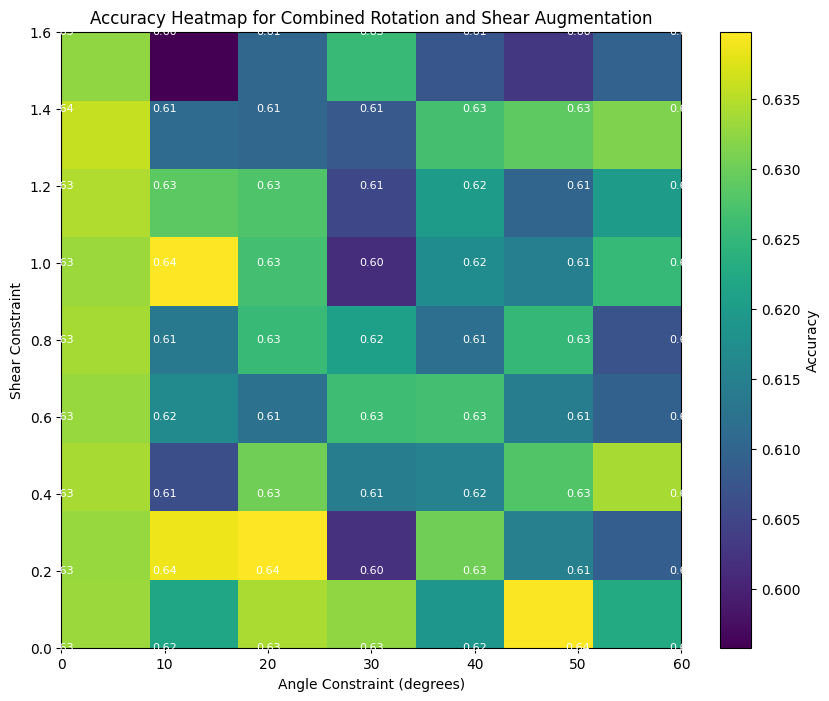

In [21]:
plt.figure(figsize=(10, 8))

accuracies_matrix = accuracies.reshape(len(shearconstraints), len(angleconstraints))

plt.imshow(accuracies_matrix, cmap='viridis', origin='lower', extent=[min(angleconstraints), max(angleconstraints), min(shearconstraints), max(shearconstraints)], aspect='auto')
plt.colorbar(label='Accuracy')
plt.xlabel('Angle Constraint (degrees)')
plt.ylabel('Shear Constraint')
plt.title('Accuracy Heatmap for Combined Rotation and Shear Augmentation')

plt.xticks(angleconstraints)
plt.yticks(shearconstraints)


for i, shear_val in enumerate(shearconstraints):
    for j, angle_val in enumerate(angleconstraints):
        plt.text(angle_val, shear_val, f'{accuracies_matrix[i, j]:.2f}', ha='center', va='center', color='white', fontsize=8)

plt.show()

question 1

the accuracy is highest for 0.6 shear of 66.52%

the accuracy is highest for 40 degrees of 68.14%

question 2

yes ,increasing argumentation  leads to the better accuracy
but accuracy decreases after secrtain point


